# LIBRARY

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from collections import defaultdict


In [54]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np

In [55]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import SMOTE

In [56]:
import numpy as np
import scipy
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from scikitplot.metrics import plot_roc
from scikitplot.metrics import plot_precision_recall
from sklearn.tree._tree import TREE_LEAF
from sklearn.tree import plot_tree, DecisionTreeRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [57]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

In [58]:
from imblearn.pipeline import Pipeline          # ← key fix
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score, classification_report

In [60]:
def print_dist(y, label, binary=False):
    unique, counts = np.unique(y, return_counts=True)
    proportions    = counts / counts.sum()
    prefix         = 'binary=' if binary else 'sii='
    df = pd.DataFrame({
        'Class':      [f'{prefix}{u}' for u in unique],
        'Count':      counts,
        'Proportion': proportions.round(4),
        'Percentage': (proportions * 100).round(2)
    })
    print(f"\n{'='*60}")
    print(f"  SET: {label}")
    print(df.to_string(index=False))

# READ DATAFRAME

In [61]:
file_path = "../1.DATASET/CMI_FINAL_OD_SS.csv"
df=pd.read_csv(file_path)

In [62]:
df

,id,Basic_Demos-Age,Basic_Demos-Sex,Physical-BMI,Physical-Height,Physical-Weight,Physical-MAP_CAL,FGC-FGC_CORE_CAL,FGC-FGC_GS_CAL,FGC-FGC_SR_CAL,BIA-BIA_Activity_Level_num,BIA-BIA_BMC,BIA-BIA_DEE,BIA-BIA_FFM,BIA-BIA_Fat,BIA-BIA_Frame_num,BIA-BIA_SMM,BIA-BIA_TBW,sii
0,0,-1.467073,-0.822843,-0.561893,-1.343231,-1.008221,-0.250870,-0.956432,-0.428812,-0.942872,-0.939966,-0.992591,-0.818300,-0.947148,-0.726336,-1.265162,-0.874740,-0.859871,2.0
1,1,-0.338700,-0.822843,-1.221382,-1.083906,-1.128018,0.630346,-0.657546,-0.367405,1.285851,-0.939966,-1.033298,-0.804797,-0.932563,-1.053662,-1.265162,-1.226847,-1.273565,0.0
2,2,-0.056607,1.215298,-0.614950,0.018225,-0.389269,-0.232187,1.018179,-1.466511,0.790579,0.280796,-0.662859,-0.199213,-0.347769,-0.314411,0.512640,-0.355318,-0.148634,0.0
3,3,-0.338700,-0.822843,-0.233502,-0.046607,-0.239523,-0.577200,0.665395,-0.367405,-0.695236,0.280796,-0.456268,0.057750,-0.249394,-0.126332,0.512640,-0.283279,0.116846,1.0
4,4,2.200139,1.215298,-0.315811,-0.224763,-0.375806,0.577087,-0.304761,1.210082,-0.198377,0.280796,3.297345,1.538145,-0.330005,-0.314411,0.512640,0.009328,-0.148634,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8377,8455,-0.902887,1.215298,-0.735189,-1.334155,-1.060626,-0.281071,-0.789840,-0.392148,-0.695236,-2.160727,-1.012064,-0.820639,-0.817405,-1.103413,-1.265162,-1.004029,-0.941197,0.0
8378,8456,-0.056607,1.215298,-0.463799,-0.029751,-0.341052,-0.490946,-0.613448,-1.251639,-1.685780,0.280796,0.067523,-0.439950,-0.015430,-0.823890,-1.265162,-0.581341,-0.582047,1.0
8379,8457,-0.056607,1.215298,5.021847,-0.881633,1.293649,-0.249437,0.533101,-0.627980,0.542943,1.501557,-0.388344,-0.705917,1.239140,0.886735,0.512640,0.152734,-0.682526,0.0
8380,8458,1.353859,1.215298,0.742981,0.963464,0.974332,0.395292,-0.481153,1.201246,1.038215,-0.939966,0.058376,-0.447250,1.092211,0.366529,0.512640,1.420549,0.963516,2.0


In [63]:
column2drop = ['id']
df.drop(column2drop, axis=1, inplace=True)
attributes = [col for col in df.columns if col != 'sii']
X = df[attributes].values
y = np.array(df['sii'])

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}")
print(f"Class counts : {dict(zip(*np.unique(y, return_counts=True)))}")


X shape : (8382, 17)
y shape : (8382,)
Classes : [0. 1. 2. 3.]
Class counts : {0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85}


# Data Preparation

In [64]:
X.shape

(8382, 17)

In [65]:
np.unique(y, return_counts=True)

(array([0., 1., 2., 3.]), array([5794, 1567,  936,   85], dtype=int64))

In [66]:
Counter(y)

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

In [67]:
ctr = Counter(y)
ctr

Counter({0.0: 5794, 1.0: 1567, 2.0: 936, 3.0: 85})

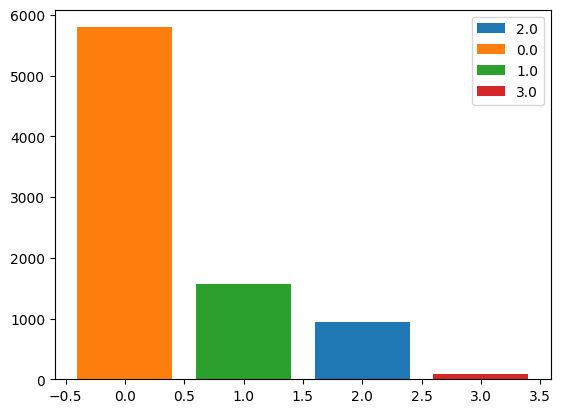

In [68]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange','tab:green','tab:red'])
plt.legend()
plt.show()

## Data Partitioning

In [69]:
from sklearn.model_selection import train_test_split, cross_val_score 

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=100, stratify=y)

In [71]:
X_train.shape

(5867, 17)

In [72]:
np.unique(y_train, return_counts=True), np.unique(y_test, return_counts=True)

((array([0., 1., 2., 3.]), array([4056, 1097,  655,   59], dtype=int64)),
 (array([0., 1., 2., 3.]), array([1738,  470,  281,   26], dtype=int64)))

In [73]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.6913243565706494

In [74]:

print(f"Train samples : {len(y_train)}")
print(f"Test samples  : {len(y_test)}")

Train samples : 5867
Test samples  : 2515


# CASCADE

## model

In [75]:
param_list = {
    'C':            [0.01,0.1, 1, 10, 100],
    'penalty':      ['l1', 'l2', 'elasticnet'],
    'solver':       ['saga'],
    'l1_ratio':     np.linspace(0, 1, 10).tolist(),
    'class_weight': ['balanced', None]
}

In [76]:
def train_one_step(X_train, y_binary, X_test, y_test_binary, step_name,
                   n_iter=50, n_splits=5, random_state=0):

    print(f"\n{'='*60}")
    print(f"  STEP: {step_name}")
    print(f"  Training samples : {len(y_binary)}")
    print(f"  Positive class   : {y_binary.sum()} samples")
    print(f"  Negative class   : {(y_binary==0).sum()} samples")
    print(f"{'='*60}")

    random_search = RandomizedSearchCV(
        LogisticRegression(random_state=random_state),
        param_distributions=param_list,       # ← list of dicts (valid combos)
        cv=KFold(n_splits=n_splits, shuffle=True, random_state=random_state),
        scoring='f1_macro',
        n_jobs=-1,
        refit=True,
        n_iter=n_iter,
        random_state=random_state,
        error_score='raise',                  # ← surface errors immediately
    )
    random_search.fit(X_train, y_binary)

    best_model = random_search.best_estimator_
    best_model.fit(X_train, y_binary)

    print(f"\n  Best params : {random_search.best_params_}")
    print(f"  Best CV F1  : {random_search.best_score_:.4f}")

    # ── Predictions ───────────────────────────────────────────────────────────
    y_pred_binary = best_model.predict(X_test)
    y_proba       = best_model.predict_proba(X_test)[:, 1]  # ← P(positive class)
                                                             #   only 2 columns in binary

    test_f1 = f1_score(y_test_binary, y_pred_binary, average='weighted')
    print(f"  Test F1     : {test_f1:.4f}")

    # ── Confusion matrix ──────────────────────────────────────────────────────
    cm   = confusion_matrix(y_test_binary, y_pred_binary)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=[f'not {step_name}', step_name]
    )
    disp.plot(cmap='Blues')
    plt.title(f'Confusion Matrix — {step_name}')
    plt.tight_layout()
    plt.show()

    # ── ROC curve ─────────────────────────────────────────────────────────────
    from sklearn.metrics import roc_curve, auc
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
    roc_auc     = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color='#7F77DD', linewidth=2,
             label=f'AUC = {roc_auc:.3f}')
    plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve — {step_name}')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # ── Reports ───────────────────────────────────────────────────────────────
    print(classification_report(y_test_binary, y_pred_binary,
                                target_names=[f'not {step_name}', step_name]))

    print(f"\n  Confusion Matrix breakdown:")
    print(f"    TN (correct negatives) : {cm[0,0]}")
    print(f"    FP (false positives)   : {cm[0,1]}")
    print(f"    FN (false negatives)   : {cm[1,0]}")
    print(f"    TP (correct positives) : {cm[1,1]}")
    print(f"    AUC                    : {roc_auc:.4f}")

    return best_model

## split 

In [77]:
# 
step_results = {}   
y_pred_final = np.full(len(X_test), -1)
original_idx = np.arange(len(X_test))

# Working copies that shrink at each cascade step
X_tr = X_train.copy()
y_tr = y_train.copy()
X_te = X_test.copy()
y_te = y_test.copy()

models  = {}
classes = np.unique(y_train)

print(f"Classes found  : {classes}")
print(f"Train samples  : {len(y_tr)}")
print(f"Test samples   : {len(y_te)}")

Classes found  : [0. 1. 2. 3.]
Train samples  : 5867
Test samples   : 2515


In [78]:
print_dist(y_tr, 'TRAIN')
print_dist(y_te, 'TEST')


  SET: TRAIN
  Class  Count  Proportion  Percentage
sii=0.0   4056      0.6913       69.13
sii=1.0   1097      0.1870       18.70
sii=2.0    655      0.1116       11.16
sii=3.0     59      0.0101        1.01

  SET: TEST
  Class  Count  Proportion  Percentage
sii=0.0   1738      0.6911       69.11
sii=1.0    470      0.1869       18.69
sii=2.0    281      0.1117       11.17
sii=3.0     26      0.0103        1.03


### class 0

In [79]:
# ── STEP 1: sii=0 vs [1, 2, 3] ───────────────────────────────────────────
y_binary_tr = (y_tr == 0).astype(int)
y_binary_te = (y_te == 0).astype(int)


In [80]:
print_dist(y_binary_tr, 'TRAIN — binary step 1', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 1', binary=True)


  SET: TRAIN — binary step 1
   Class  Count  Proportion  Percentage
binary=0   1811      0.3087       30.87
binary=1   4056      0.6913       69.13

  SET: TEST  — binary step 1
   Class  Count  Proportion  Percentage
binary=0    777      0.3089       30.89
binary=1   1738      0.6911       69.11


In [81]:
# from imblearn.over_sampling import SMOTE
# over_dic={0:3500}
# #under_dic={0:3000}
# over = SMOTE(random_state=42, sampling_strategy=over_dic)
# #under = TomekLinks(sampling_strategy='majority')
# X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
# print('Resampled dataset shape %s' % Counter(y_res))


  STEP: sii=0
  Training samples : 5867
  Positive class   : 4056 samples
  Negative class   : 1811 samples

  Best params : {'solver': 'saga', 'penalty': 'l1', 'l1_ratio': 0.4444444444444444, 'class_weight': 'balanced', 'C': 0.01}
  Best CV F1  : 0.6113
  Test F1     : 0.6589


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.4444444444444444. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was dep

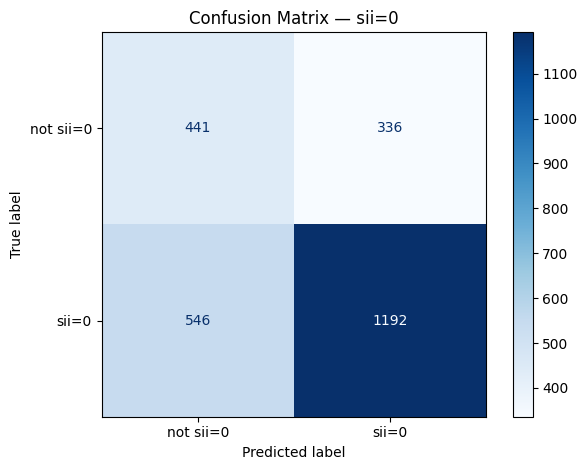

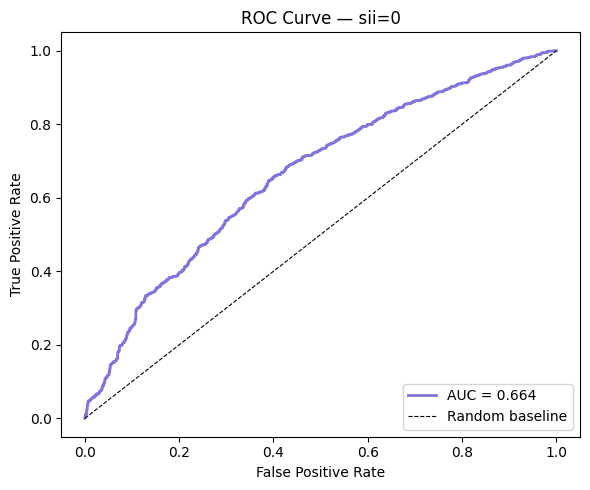

              precision    recall  f1-score   support

   not sii=0       0.45      0.57      0.50       777
       sii=0       0.78      0.69      0.73      1738

    accuracy                           0.65      2515
   macro avg       0.61      0.63      0.61      2515
weighted avg       0.68      0.65      0.66      2515


  Confusion Matrix breakdown:
    TN (correct negatives) : 441
    FP (false positives)   : 336
    FN (false negatives)   : 546
    TP (correct positives) : 1192
    AUC                    : 0.6635


In [82]:
models[0] = train_one_step(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=0')

In [83]:
# samples predicted as sii=0 → assign 0 to their original position
y_pred_te   = models[0].predict(X_te)

#----------------------------------
step_results[0] = {
    'step_name':    'sii=0 vs [1,2,3]',
    'y_true_bin':   y_binary_te.copy(),      # verdadero binario
    'y_pred_bin':   y_pred_te.copy(),        # predicho binario
    'y_true_orig':  y_te.copy(),             # verdadero multiclass en este paso
    'original_idx': original_idx.copy(),     # índices originales
}

y_pred_final[original_idx[y_pred_te == 1]] = 0

print(f"\n  Assigned as sii=0 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=0 : 1528 samples


### class 1 

In [84]:
# TRAIN → remove all true sii=0 
mask_tr      = y_tr != 0
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink index tracker too

In [85]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 1')
print_dist(y_te, 'TEST  after step 1')

  Remaining train : 1811
  Remaining test  : 1323

  SET: TRAIN after step 1
  Class  Count  Proportion  Percentage
sii=1.0   1097      0.6057       60.57
sii=2.0    655      0.3617       36.17
sii=3.0     59      0.0326        3.26

  SET: TEST  after step 1
  Class  Count  Proportion  Percentage
sii=0.0    546      0.4127       41.27
sii=1.0    470      0.3553       35.53
sii=2.0    281      0.2124       21.24
sii=3.0     26      0.0197        1.97


In [86]:
y_binary_tr = (y_tr == 1).astype(int)
y_binary_te = (y_te == 1).astype(int)

In [87]:
print_dist(y_binary_tr, 'TRAIN — binary step 2', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 2', binary=True)


  SET: TRAIN — binary step 2
   Class  Count  Proportion  Percentage
binary=0    714      0.3943       39.43
binary=1   1097      0.6057       60.57

  SET: TEST  — binary step 2
   Class  Count  Proportion  Percentage
binary=0    853      0.6447       64.47
binary=1    470      0.3553       35.53



  STEP: sii=1
  Training samples : 1811
  Positive class   : 1097 samples
  Negative class   : 714 samples

  Best params : {'solver': 'saga', 'penalty': 'l1', 'l1_ratio': 0.2222222222222222, 'class_weight': 'balanced', 'C': 0.1}
  Best CV F1  : 0.5731
  Test F1     : 0.6293


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1152: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.2222222222222222. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was dep

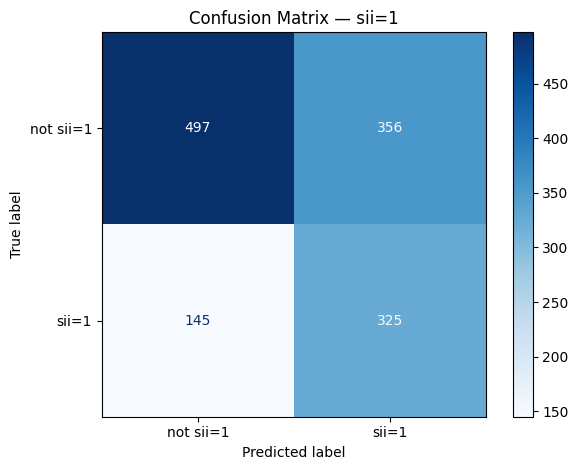

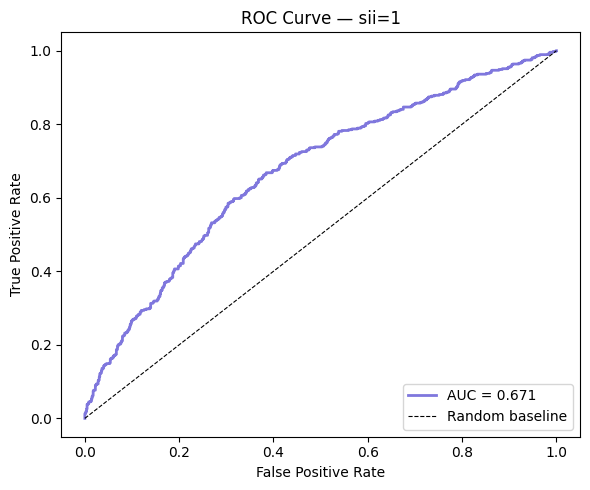

              precision    recall  f1-score   support

   not sii=1       0.77      0.58      0.66       853
       sii=1       0.48      0.69      0.56       470

    accuracy                           0.62      1323
   macro avg       0.63      0.64      0.61      1323
weighted avg       0.67      0.62      0.63      1323


  Confusion Matrix breakdown:
    TN (correct negatives) : 497
    FP (false positives)   : 356
    FN (false negatives)   : 145
    TP (correct positives) : 325
    AUC                    : 0.6712


In [88]:
models[1] = train_one_step(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=1')

In [89]:
y_pred_te   = models[1].predict(X_te)

step_results[1] = {
    'step_name':    'sii=1 vs [2,3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 1

print(f"\n  Assigned as sii=1 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=1 : 681 samples


### class 2

In [90]:
# TRAIN → remove all true sii=1
mask_tr      = y_tr != 1
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

# TEST → remove only TRUE POSITIVES 
tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

In [91]:
print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")
print_dist(y_tr, 'TRAIN after step 2')
print_dist(y_te, 'TEST  after step 2')

  Remaining train : 714
  Remaining test  : 998

  SET: TRAIN after step 2
  Class  Count  Proportion  Percentage
sii=2.0    655      0.9174       91.74
sii=3.0     59      0.0826        8.26

  SET: TEST  after step 2
  Class  Count  Proportion  Percentage
sii=0.0    546      0.5471       54.71
sii=1.0    145      0.1453       14.53
sii=2.0    281      0.2816       28.16
sii=3.0     26      0.0261        2.61


In [92]:
y_binary_tr = (y_tr == 2).astype(int)
y_binary_te = (y_te == 2).astype(int)

In [93]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0     59      0.0826        8.26
binary=1    655      0.9174       91.74

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    717      0.7184       71.84
binary=1    281      0.2816       28.16


In [94]:
# from imblearn.over_sampling import SMOTE
# over_dic={0:500}
# #under_dic={0:3000}
# over = SMOTE(random_state=42, sampling_strategy=over_dic)
# #under = TomekLinks(sampling_strategy='majority')
# X_res, y_res = over.fit_resample(X_tr, y_binary_tr)
# print('Resampled dataset shape %s' % Counter(y_res))


In [95]:
print_dist(y_binary_tr, 'TRAIN — binary step 3', binary=True)
print_dist(y_binary_te, 'TEST  — binary step 3', binary=True)


  SET: TRAIN — binary step 3
   Class  Count  Proportion  Percentage
binary=0     59      0.0826        8.26
binary=1    655      0.9174       91.74

  SET: TEST  — binary step 3
   Class  Count  Proportion  Percentage
binary=0    717      0.7184       71.84
binary=1    281      0.2816       28.16



  STEP: sii=2
  Training samples : 714
  Positive class   : 655 samples
  Negative class   : 59 samples

  Best params : {'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.1111111111111111, 'class_weight': 'balanced', 'C': 0.01}
  Best CV F1  : 0.4790
  Test F1     : 0.5033


c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\paula\anaconda3\envs\datascience\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


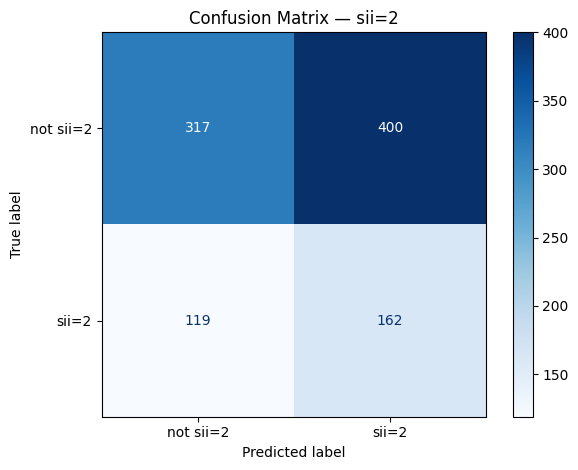

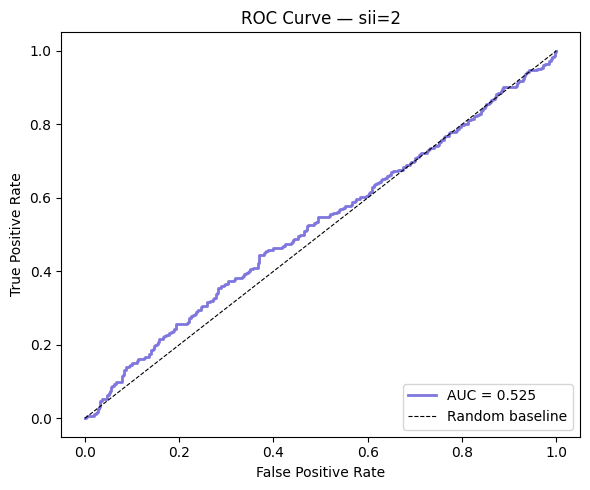

              precision    recall  f1-score   support

   not sii=2       0.73      0.44      0.55       717
       sii=2       0.29      0.58      0.38       281

    accuracy                           0.48       998
   macro avg       0.51      0.51      0.47       998
weighted avg       0.60      0.48      0.50       998


  Confusion Matrix breakdown:
    TN (correct negatives) : 317
    FP (false positives)   : 400
    FN (false negatives)   : 119
    TP (correct positives) : 162
    AUC                    : 0.5250


In [96]:
models[2] = train_one_step(X_tr, y_binary_tr, X_te, y_binary_te,
                            step_name='sii=2')

In [97]:
# ── Assign predictions for step 3 ────────────────────────────────────────────
y_pred_te   = models[2].predict(X_te)

step_results[2] = {
    'step_name':    'sii=2 vs [3]',
    'y_true_bin':   y_binary_te.copy(),
    'y_pred_bin':   y_pred_te.copy(),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

y_pred_final[original_idx[y_pred_te == 1]] = 2

print(f"\n  Assigned as sii=2 : {(y_pred_te == 1).sum()} samples")


  Assigned as sii=2 : 562 samples


### class 3 

In [98]:
# ── Filter for next step ──────────────────────────────────────────────────────
mask_tr      = y_tr != 2
X_tr, y_tr   = X_tr[mask_tr], y_tr[mask_tr]

tp_mask_te   = (y_pred_te == 1) & (y_binary_te == 1)
mask_te      = ~tp_mask_te
X_te, y_te         = X_te[mask_te],   y_te[mask_te]
original_idx       = original_idx[mask_te]           # ← shrink again

print(f"  Remaining train : {len(y_tr)}")
print(f"  Remaining test  : {len(y_te)}")

  Remaining train : 59
  Remaining test  : 836


In [99]:
y_pred_final[original_idx] = 3
step_results[3] = {
    'step_name':    'sii=3 (remaining)',
    'y_true_bin':   (y_te == 3).astype(int),
    'y_pred_bin':   np.ones(len(y_te), dtype=int),
    'y_true_orig':  y_te.copy(),
    'original_idx': original_idx.copy(),
}

print(f"\n  Assigned as sii=3 : {len(original_idx)} samples (all remaining)")


  Assigned as sii=3 : 836 samples (all remaining)


# RESULTS

In [100]:
# ══════════════════════════════════════════════════════════════════════════════
# REPORTE COMBINADO
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_score, recall_score, f1_score

print("\n" + "="*75)
print("  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS")
print("="*75)

rows = []
for step, res in step_results.items():
    yt = res['y_true_bin']
    yp = res['y_pred_bin']

    # métricas binarias reales de cada paso
    prec   = precision_score(yt, yp, zero_division=0)
    rec    = recall_score(yt, yp, zero_division=0)
    f1     = f1_score(yt, yp, zero_division=0)
    n      = len(yt)
    n_pos  = yt.sum()
    tp     = ((yp == 1) & (yt == 1)).sum()
    fp     = ((yp == 1) & (yt == 0)).sum()
    fn     = ((yp == 0) & (yt == 1)).sum()

    rows.append({
        'Step':         res['step_name'],
        'N samples':    n,
        'N positive':   n_pos,
        'TP':           tp,
        'FP':           fp,
        'FN':           fn,
        'Precision':    round(prec, 4),
        'Recall':       round(rec,  4),
        'F1':           round(f1,   4),
    })

report_df = pd.DataFrame(rows)
print(report_df.to_string(index=False))


  COMBINED PERFORMANCE REPORT — BINARY vs MULTICLASS
             Step  N samples  N positive   TP  FP  FN  Precision  Recall     F1
 sii=0 vs [1,2,3]       2515        1738 1192 336 546     0.7801  0.6858 0.7299
   sii=1 vs [2,3]       1323         470  325 356 145     0.4772  0.6915 0.5647
     sii=2 vs [3]        998         281  162 400 119     0.2883  0.5765 0.3843
sii=3 (remaining)        836          26   26 810   0     0.0311  1.0000 0.0603


In [101]:
# ── Multiclass final ──────────────────────────────────────────────────────────
print("\n" + "="*75)
print("  FINAL MULTICLASS REPORT (y_test vs y_pred_final)")
print("="*75)
print(classification_report(
    y_test, y_pred_final,
    target_names=['sii=0', 'sii=1', 'sii=2', 'sii=3']
))


  FINAL MULTICLASS REPORT (y_test vs y_pred_final)
              precision    recall  f1-score   support

       sii=0       1.00      0.69      0.81      1738
       sii=1       1.00      0.69      0.82       470
       sii=2       1.00      0.58      0.73       281
       sii=3       0.03      1.00      0.06        26

    accuracy                           0.68      2515
   macro avg       0.76      0.74      0.61      2515
weighted avg       0.99      0.68      0.80      2515



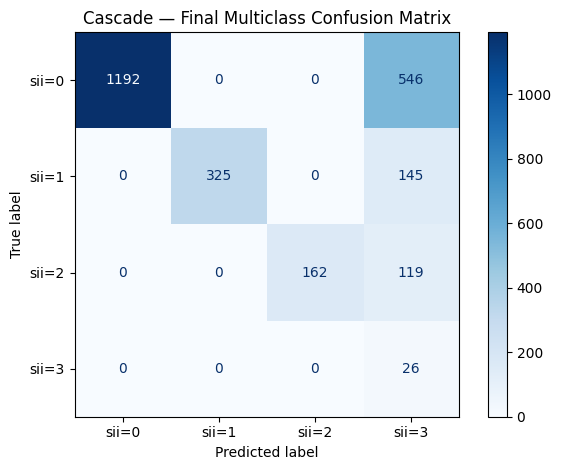

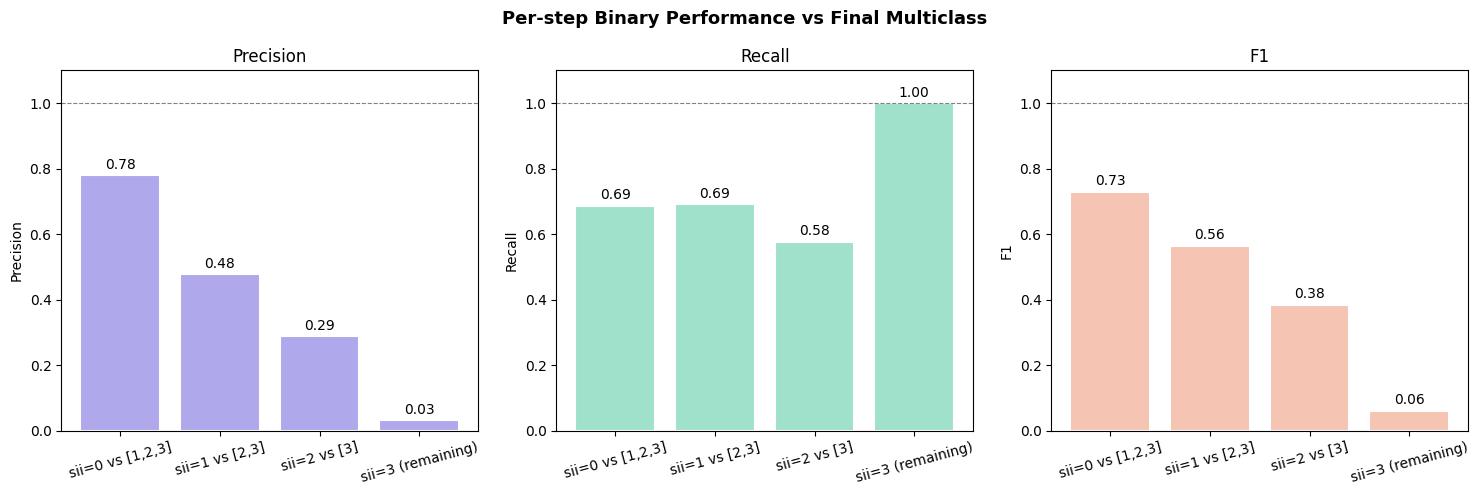

In [102]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_final, labels=[0, 1, 2, 3])
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['sii=0', 'sii=1', 'sii=2', 'sii=3']
)
disp.plot(cmap='Blues')
plt.title('Cascade — Final Multiclass Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Plot comparativo ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['Precision', 'Recall', 'F1']
colors    = ['#AFA9EC', '#9FE1CB', '#F5C4B3']

for ax, metric, color in zip(axes, metrics, colors):
    steps  = [r['Step'] for r in rows]
    values = [r[metric] for r in rows]
    bars   = ax.bar(steps, values, color=color, edgecolor='white', linewidth=1.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=15)
    ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', fontsize=10)

plt.suptitle('Per-step Binary Performance vs Final Multiclass',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [103]:
# ── Per class summary ─────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print("  PREDICTIONS SUMMARY")
print(f"{'='*60}")
for cls in [0, 1, 2, 3]:
    true_count = (y_test == cls).sum()
    pred_count = (y_pred_final == cls).sum()
    print(f"  sii={cls} → true: {true_count:<6} predicted: {pred_count}")


  PREDICTIONS SUMMARY
  sii=0 → true: 1738   predicted: 1192
  sii=1 → true: 470    predicted: 325
  sii=2 → true: 281    predicted: 162
  sii=3 → true: 26     predicted: 836


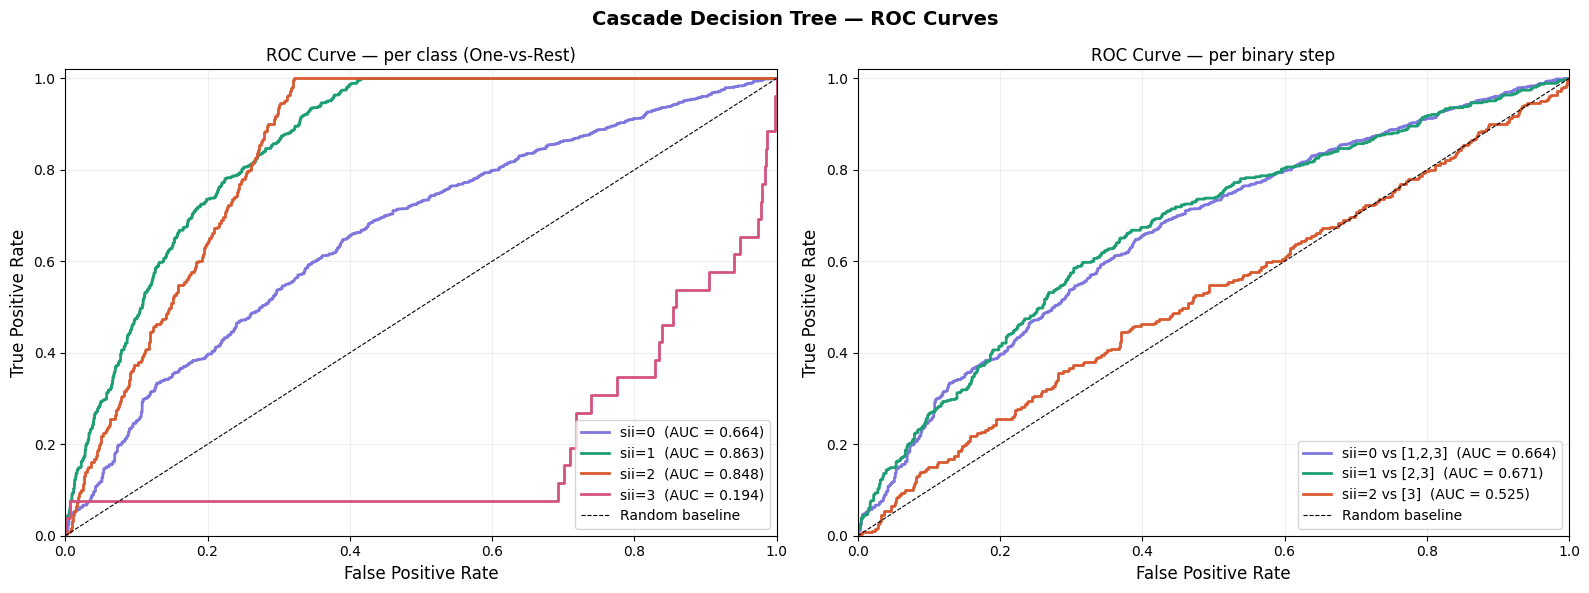


  AUC SUMMARY
  sii=0    → AUC = 0.6635
  sii=1    → AUC = 0.8628
  sii=2    → AUC = 0.8476
  sii=3    → AUC = 0.1940

  Macro AUC    : 0.6420
  Weighted AUC : 0.7165


In [104]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ── 1. Collect probabilities from each step ───────────────────────────────────
# Each model gives P(class=X) for the samples it saw
# We need to reconstruct full probability matrix (n_test, 4)

n_test     = len(X_test)
proba_full = np.zeros((n_test, 4))   # one column per class

for step, res in step_results.items():
    idx    = res['original_idx']          # which original test samples this step saw
    model  = models.get(step)

    if model is not None:
        proba_step         = model.predict_proba(X_test[idx])   # shape (n_step, 2)
        proba_full[idx, step] = proba_step[:, 1]                # P(positive) for this class
    else:
        # last class — use survival probability (1 - sum of previous)
        proba_full[idx, step] = 1 - proba_full[idx, :step].sum(axis=1)

# ── 2. Binarize y_test for multiclass ROC ────────────────────────────────────
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3])  # shape (n_test, 4)

# ── 3. Compute ROC per class ──────────────────────────────────────────────────
colors     = ['#7F77DD', '#1D9E75', '#D85A30', '#D4537E']
step_names = ['sii=0', 'sii=1', 'sii=2', 'sii=3']

fpr_dict = {}
tpr_dict = {}
auc_dict = {}

for i in range(4):
    fpr_dict[i], tpr_dict[i], _ = roc_curve(y_test_bin[:, i], proba_full[:, i])
    auc_dict[i]                  = auc(fpr_dict[i], tpr_dict[i])

# ── 4. Plot — two panels ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel 1 — individual ROC per class ───────────────────────────────────────
ax = axes[0]
for i in range(4):
    ax.plot(fpr_dict[i], tpr_dict[i],
            color=colors[i],
            linewidth=2,
            label=f"{step_names[i]}  (AUC = {auc_dict[i]:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per class (One-vs-Rest)', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

# ── Panel 2 — step by step binary ROC ────────────────────────────────────────
ax = axes[1]
for step, res in step_results.items():
    model = models.get(step)
    if model is None:
        continue                              # skip last class (no model)

    idx        = res['original_idx']
    y_true_bin = res['y_true_bin']
    y_proba    = model.predict_proba(X_test[idx])[:, 1]

    fpr, tpr, _ = roc_curve(y_true_bin, y_proba)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr,
            color=colors[step],
            linewidth=2,
            label=f"{step_results[step]['step_name']}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curve — per binary step', fontsize=12)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.grid(alpha=0.2)

plt.suptitle('Cascade Decision Tree — ROC Curves',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 5. Print AUC summary ──────────────────────────────────────────────────────
print("\n" + "="*45)
print("  AUC SUMMARY")
print("="*45)
for i in range(4):
    print(f"  {step_names[i]:<8} → AUC = {auc_dict[i]:.4f}")

from sklearn.metrics import roc_auc_score
macro    = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='macro')
weighted = roc_auc_score(y_test_bin, proba_full, multi_class='ovr', average='weighted')
print(f"\n  Macro AUC    : {macro:.4f}")
print(f"  Weighted AUC : {weighted:.4f}")
print("="*45)